### NPi reontruction using only max and min

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l
from scipy.optimize import curve_fit
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression


In [ ]:
# Load data
df = pd.read_csv("../Modified_Pupilometri/NPImeaures_noCHerror.csv")

df["eye"] = df["eye"].map({"left": 0, "right": 1})

df["redcap_repeat_instance"] = (
    df["redcap_repeat_instance"]
    .fillna(0)
    .astype(int)
)

df = df.dropna(subset=[
    "npi", "pupil_size", "pupil_min"
])
def z_score(x, mean, std):
    return (x - mean) / std

# use the z-scores from healthy controls
df_l = pd.read_csv("../Pupilometri/HC_left_NPi.csv")
df_r = pd.read_csv("../Pupilometri/HC_right_NPi.csv")
df_l = df_l.rename(columns=lambda c: c.replace("_left", ""))
df_r = df_r.rename(columns=lambda c: c.replace("_right", ""))

df_l["eye"] = "left"
df_r["eye"] = "right"

df_HC = pd.concat([df_l, df_r], ignore_index=True)

df["z_pupil_size"] = z_score(df["pupil_size"], df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
df["z_pupil_min"]  = z_score(df["pupil_min"], df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())


TARGET = "npi"
GROUP = "record_id"
FEATURES = [
    "z_pupil_size",
    "z_pupil_min"
]

X = df[FEATURES].copy()
y_raw = df[TARGET].astype(float).values
groups = df[GROUP].values


X_trans = X.copy()


In [ ]:
# Functions for the features
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Pupil min model
def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

# pupil size model
def sigmoid_plus_threshold_linear(x, A, k, x0, m, b, x_thresh):
    return A * sigmoid(k * (x - x0)) + m * np.maximum(0, x - x_thresh) + b



# Stratified CV setup
y_binned = pd.qcut(df["npi"], q=5, labels=False, duplicates="drop")

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores, mae_scores, r2_scores = [], [], []

all_true = []
all_pred = []
all_indices = []

# CV LOOP

for fold, (train_idx, test_idx) in enumerate(cv.split(X_trans, y_binned, groups)):

    print(f"\n--- Fold {fold+1} ---")

    X_train = X_trans.iloc[train_idx]
    X_test  = X_trans.iloc[test_idx]

    y_train_raw = y_raw[train_idx]
    y_test_raw  = y_raw[test_idx]

  
    # Logit transform

    y_train_scaled = np.clip(y_train_raw / 5, 1e-6, 1-1e-6)
    z_train = np.log(y_train_scaled / (1 - y_train_scaled))


    # Train GAM
  
    gam = LinearGAM(
        s(0, n_splines=20) +
        s(1, constraints='monotonic_dec', n_splines=10) 
    )

    gam.gridsearch(X_train, z_train)

  
    # fit model
  
    # Pupil size 
    x_vals_size = np.linspace(X_train.iloc[:,0].min(), X_train.iloc[:,0].max(), 200)

    X_fake = pd.DataFrame(
        np.tile(X_train.mean().values, (200,1)),
        columns=X_train.columns
    )
    X_fake.iloc[:,0] = x_vals_size

    y_gam_size = gam.partial_dependence(term=0, X=X_fake)

    try:
        lower_bounds = [0, 0.01, x_vals_size.min(), -5, -10, x_vals_size.min()]
        upper_bounds = [10,10, x_vals_size.max(),  5,  10,  x_vals_size.max()]

        p0 = [
            y_gam_size.max() - y_gam_size.min(),
            1,
            np.median(x_vals_size),
            0.1,
            np.mean(y_gam_size),
            np.median(x_vals_size)
        ]

        p0 = np.clip(p0, lower_bounds, upper_bounds)

        params_size, _ = curve_fit(
            sigmoid_plus_threshold_linear,
            x_vals_size,
            y_gam_size,
            p0=p0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=20000
        )
        use_fallback_size = False
    except RuntimeError:
        print("failed")
        use_fallback_size = True


    # Pupil min 
    x_vals_min = np.linspace(X_train.iloc[:,1].min(), X_train.iloc[:,1].max(), 200)

    X_fake = pd.DataFrame(
        np.tile(X_train.mean().values, (200,1)),
        columns=X_train.columns
    )
    X_fake.iloc[:,1] = x_vals_min

    y_gam_min = gam.partial_dependence(term=1, X=X_fake)

    params_min, _ = curve_fit(exp_decay, x_vals_min, y_gam_min, maxfev=10000)




    # Linear terms
    intercept = (
        gam._modelmat(np.zeros((1, X_train.shape[1]))) @ gam.coef_
    ).item()



    # MODEL
    def f_size(x):
        if use_fallback_size:
            return np.interp(x, x_vals_size, y_gam_size)
        return sigmoid_plus_threshold_linear(x, *params_size)

    def f_min(x):
        return exp_decay(x, *params_min)


    def predict_z(X):
        return (
            intercept
            + f_size(X.iloc[:,0].values)
            + f_min(X.iloc[:,1].values)

        )

    # CALIBRATION

    z_train_pred = predict_z(X_train)

    z_train_true = np.log(
        np.clip(y_train_raw/5, 1e-6, 1-1e-6) /
        (1 - np.clip(y_train_raw/5, 1e-6, 1-1e-6))
    )

    reg = LinearRegression().fit(
        z_train_pred.reshape(-1,1),
        z_train_true
    )

    a = reg.coef_[0]
    b = reg.intercept_

    print(f"Calibration: a={a:.3f}, b={b:.3f}")



    # Test
    z_test_pred = predict_z(X_test)

    z_test_corrected = a * z_test_pred + b
    npi_pred = np.round(sigmoid(z_test_corrected) * 5,1)
    all_true.extend(y_test_raw)
    all_pred.extend(npi_pred)
    all_indices.extend(test_idx)



   
    # Evaluation

    rmse = np.sqrt(mean_squared_error(y_test_raw, npi_pred))
    mae  = mean_absolute_error(y_test_raw, npi_pred)
    r2   = r2_score(y_test_raw, npi_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)


# Results
print("\n=== FINAL CV RESULTS ===")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"MAE:  {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"R2:   {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--



--- Fold 1 ---


  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:05
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:02
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:01
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00


Calibration: a=0.884, b=-0.277
RMSE: 0.2008
MAE:  0.1340
R2:   0.9272

--- Fold 2 ---


 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00


...

Calibration: a=0.849, b=-0.437
RMSE: 0.2185
MAE:  0.1635
R2:   0.8517

--- Fold 4 ---


 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00


Calibration: a=0.902, b=-0.521
RMSE: 0.1864
MAE:  0.1268
R2:   0.9252

--- Fold 5 ---


 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Calibration: a=0.856, b=-0.374
RMSE: 0.2210
MAE:  0.1587
R2:   0.8747

=== FINAL CV RESULTS ===
RMSE: 0.2128 ± 0.0176
MAE:  0.1508 ± 0.0173
R2:   0.8858 ± 0.0342


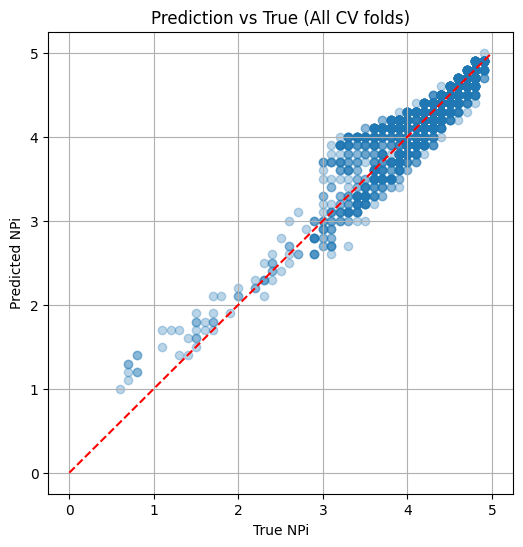

In [ ]:


all_true = np.array(all_true)
all_pred = np.array(all_pred)

plt.figure(figsize=(6,6))
plt.scatter(all_true, all_pred, alpha=0.3)

# perfect prediction line
plt.plot([0,5],[0,5],'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True (All CV folds)")
plt.grid()
plt.show()

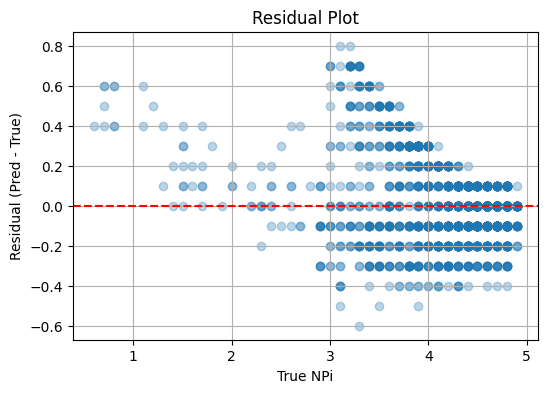

In [6]:
residuals = all_pred - all_true

plt.figure(figsize=(6,4))
plt.scatter(all_true, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("True NPi")
plt.ylabel("Residual (Pred - True)")
plt.title("Residual Plot")
plt.grid()
plt.show()

In [7]:
all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_indices = np.array(all_indices)

residuals = all_pred - all_true
errors = np.abs(residuals)

top4_idx = np.argsort(errors)[-2:]
top4_rows = df.iloc[all_indices[top4_idx]].copy()

top4_rows["True NPi"] = all_true[top4_idx]
top4_rows["Predicted NPi"] = all_pred[top4_idx]
top4_rows["Residual"] = residuals[top4_idx]
top4_rows["Abs Error"] = errors[top4_idx]

# print(top4_rows.sort_values("Abs Error", ascending=False)) # Commented out for privacy reasons


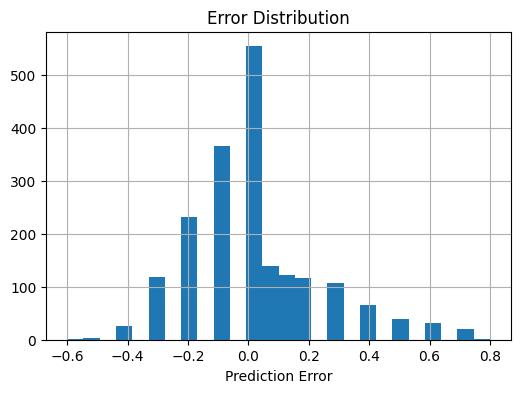

In [8]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=26)

plt.xlabel("Prediction Error")
plt.title("Error Distribution")
plt.grid()
plt.show()
